<a href="https://colab.research.google.com/github/mrojash97/dataanalytics/blob/main/Python/AN%C3%81LISIS_EDA_Supermarket_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📊Análisis Exploratorio de Datos - Supermarket Sales**
**Autor:** MARLON ROJAS HUARIPATA  
**Fecha:** 04/2025  
**Descripción:** Exploraremos y visualizaremos los datos de ventas de un supermercado. Dataset obtenida de Kaggle.

## 📑 Tabla de Contenidos

1. [📘 Objetivos ](#obj)
2. [🛠️ Importación de Librerias](#lib)
3. [🔄 Carga de Datos](#datos)
4. [📑 Preparando Datos](#prep)
5. [📊 Análisis Exploratorio de Datos (EDA)](#eda)
6. [📈 Visualizaciones Interactivas](#vis)
7. [🛠️ Herramientas y Utilidades](#tools)
8. [📦 Proyectos Destacados](#proyectos)
9. [📚 Recursos y Enlaces](#recursos)


### **📘 Objetivos** <a name="obj"></a>



**Objetivo Principal:**

Evaluar y comprender el comportamiento de las ventas en las sedes, los productos, los clientes, para tomar decisiones informadas que optimicen los procesos comerciales, aumenten la rentabilidad y mejoren la experiencia del cliente.

**Objetivos Específicos:**

1. **Identificar patrones de compra:** Conocer las preferencias de consumo por sucursal, categoría de producto y método de pago para determinar las sucursales y líneas de producto más rentables.
2. **Evaluar la demanda de los productos:**  Conocer la demanda de los productos, por sede, categoría y  la evolución de ventas mensuales, para enfocar las estrategias de marketing.
3. **Mejorar la gestión de personal y productos:** Conocer los días y horas de mayor actividad, para organizar al personal y tener mayor control del inventario.
4. **Evaluación de clientes:** Evaluar las calificaciones por sucursal, tipo de cliente, método de pago, línea de producto. Para entender el comportamiento del consumidor al calificar y mejorar su experiencia.




### **🛠️ Importación de Librerias** <a name="lib"></a>



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **🔄 Carga de Datos** <a name="datos"></a>



In [2]:
#Cargar datos
url_data="https://drive.google.com/uc?id=1oaCwwTcv1FsT9gNAZAxFbEcdCnuaW04C"

data = pd.read_csv(url_data)
#Mostrar datos
print(data.shape)
data.head(5)

(1000, 17)


,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### **📑 Preparando Datos** <a name="prep"></a>



In [3]:
#Información de la base de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   object 
 1   branch           1000 non-null   object 
 2   city             1000 non-null   object 
 3   customer_type    1000 non-null   object 
 4   gender_customer  1000 non-null   object 
 5   product_line     1000 non-null   object 
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   object 
 11  time             1000 non-null   object 
 12  payment_method   1000 non-null   object 
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), 

In [4]:
#Ver la cantidad de datos y variables
data.shape

(1000, 17)

In [5]:
#Validar si tenemos datos nulos
data.isnull().sum()

,0
invoice_id,0
branch,0
city,0
customer_type,0
gender_customer,0
product_line,0
unit_cost,0
quantity,0
5pct_markup,0
revenue,0


In [6]:
#Validar si tenemos datos duplicados
data.duplicated().sum()

np.int64(0)

In [10]:
#Convertir el tipo de la variable date
data['date'] = pd.to_datetime(data['date'], format='%m/%d/%y', errors='coerce')
data['date'] = data['date'].combine_first(pd.to_datetime(data['date'], format='%m/%d/%Y', errors='coerce'))

# Extraer componentes de fecha y hora
data['day_of_week'] = data['date'].dt.day_name()
data['hour'] = data['time'].str.split(':').str[0].astype(int)

data.head()


,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating,day_of_week,hour
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,Saturday,13
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,Friday,10
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,Sunday,13
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,NaT,20:33,Ewallet,465.76,4.761905,23.2880,8.4,NaN,20
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,Friday,10


### **📊 Análisis Exploratorio de Datos (EDA)** <a name="eda"></a>



**OBJETIVO 1.**

Conocer las preferencias de consumo por sucursal, categoría de producto, método de pago y tipo de cleinte. Para determinar las sucursales y líneas de producto más rentables.

Agrupamos los datos a evaluar

In [11]:
# Ventas totales por sede, producto y cliente.

# Agrupar por sede, producto y cliente y sumar las ventas
ventas_totales = data.groupby(['branch', 'product_line', 'customer_type'])['gross_income'].sum().reset_index()

# Mostrar el resultado
print("=== VENTAS TOTALES POR SEDE, PRODUCTO Y CLIENTE ===")
ventas_totales


=== VENTAS TOTALES POR SEDE, PRODUCTO Y CLIENTE ===


,branch,product_line,customer_type,gross_income
0,A,Electronic accessories,Member,435.5090
1,A,Electronic accessories,Normal,436.7345
2,A,Fashion accessories,Member,330.5990
3,A,Fashion accessories,Normal,447.1395
4,A,Food and beverages,Member,422.7170
5,A,Food and beverages,Normal,394.5735
6,A,Health and beauty,Member,306.6140
7,A,Health and beauty,Normal,293.2790
8,A,Home and lifestyle,Member,597.9190
9,A,Home and lifestyle,Normal,469.5665


In [12]:
# Obtner los ingresos totales en toda la cadena

# Calculando Total de ingresos'gross_income'
total_Ingresos = data['gross_income'].sum()

# Imprimir el resultado
print(f"Los ingresos totales son: {total_Ingresos}")

Los ingresos totales son: 15379.368999999999


In [13]:
# ::INGRESOS TOTALES POR SEDE::

# Usamos la función groupby() para agrupar los datos por la columna sucursal, que representa las ramas A, B y C.
ingresos_por_sede = data.groupby('branch')['gross_income'].sum()

# Ordenar los ingresos totales en Descendente
suc_mayor_ingreso = ingresos_por_sede.sort_values(ascending=False)

# Imprimir los resultados
print("Ingresos totales por sede:")
suc_mayor_ingreso



Ingresos totales por sede:


,gross_income
branch,
C,5265.1765
A,5057.1605
B,5057.0320


Se puede notar que la rentabilidad de las sucursales hay un equilibrio, con una pequeña diferencia de la sede C

In [14]:
# ventas_totales: ventas totales por producto

# Agrupar por línea de producto y sumar ingresos gross income
ventas_por_producto = ventas_totales.groupby('product_line')['gross_income'].sum()

# Ordenar los resultados en orden descendente
ventas_por_producto_ordenadas = ventas_por_producto.sort_values(ascending=False)

# Mostrar los resultados
ventas_por_producto_ordenadas

,gross_income
product_line,
Food and beverages,2673.5640
Sports and travel,2624.8965
Electronic accessories,2587.5015
Fashion accessories,2585.9950
Home and lifestyle,2564.8530
Health and beauty,2342.5590


In [15]:
# Media total de ventas de clientes por tipo

# Agrupar por tipo de cliente y promediar la ganacia
media_ventas_cliente = data.groupby('customer_type')['gross_income'].mean()

# Imprimir el resultado
print("Promedio de Ventas totales por tipo de cliente:")
media_ventas_cliente


Promedio de Ventas totales por tipo de cliente:


,gross_income
customer_type,
Member,15.609110
Normal,15.148707


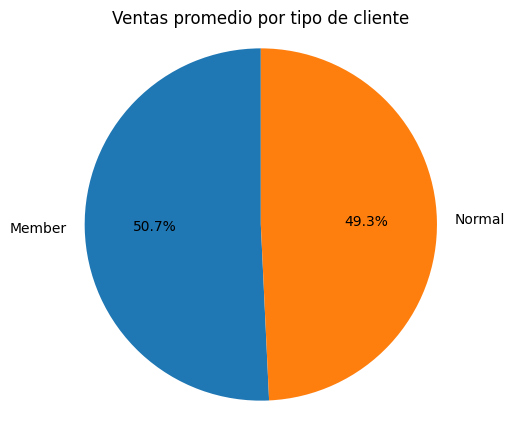

In [16]:
# Grafica de ventas por tipo de cliente

# Importar librerías
import matplotlib.pyplot as plt

# Crear el gráfico de torta
plt.figure(figsize=(5, 5))  # Ajustar el tamaño de la figura (opcional)
plt.pie(media_ventas_cliente, labels=media_ventas_cliente.index, autopct='%1.1f%%', startangle=90)
plt.title('Ventas promedio por tipo de cliente')
plt.axis('equal')  # Asegura que el gráfico de torta sea circular
plt.show()


Notamos que mayor promedio de ventas es para socios, lo que es rentable lograr capatar más socios

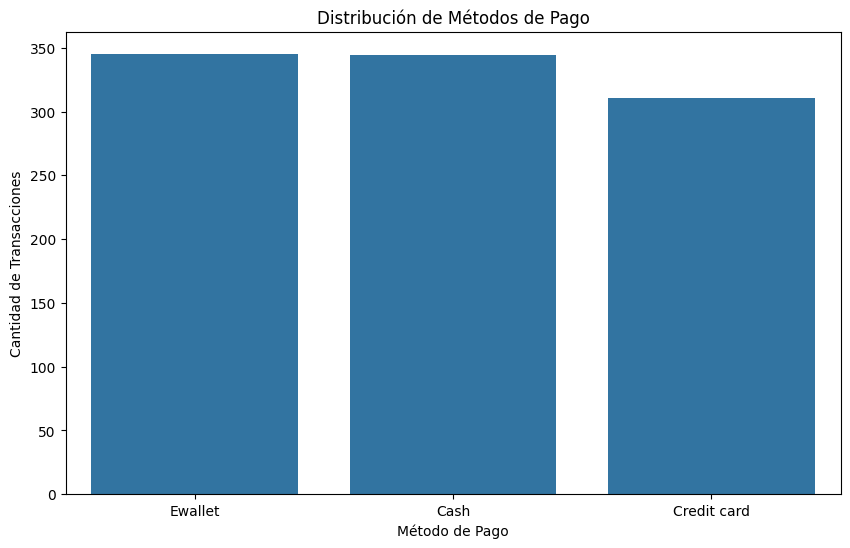

In [17]:
#Grafica de distribución de metodos de pago

# Gráfica de distribución de métodos de pago
plt.figure(figsize=(10, 6))
sns.countplot(x='payment_method', data=data)
plt.title('Distribución de Métodos de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Transacciones')
plt.show()


Se puede apreciar que las tarjetas de crédito el método con menor uso en las compras

In [18]:
# Productos más rentables por sucursal:

productos_rentables_sucursal = data.groupby(['branch', 'product_line'])['gross_income'].sum().reset_index()

productos_rentables_sucursal = productos_rentables_sucursal.sort_values(['branch', 'gross_income'], ascending=[True, False])

print("\nProductos más rentables por sucursal:")
print(productos_rentables_sucursal)


Productos más rentables por sucursal:
   branch            product_line  gross_income
4       A      Home and lifestyle     1067.4855
5       A       Sports and travel      922.5095
0       A  Electronic accessories      872.2435
2       A      Food and beverages      817.2905
1       A     Fashion accessories      777.7385
3       A       Health and beauty      599.8930
11      B       Sports and travel      951.8190
9       B       Health and beauty      951.4600
10      B      Home and lifestyle      835.6745
6       B  Electronic accessories      811.9735
7       B     Fashion accessories      781.5865
8       B      Food and beverages      724.5185
14      C      Food and beverages     1131.7550
13      C     Fashion accessories     1026.6700
12      C  Electronic accessories      903.2845
15      C       Health and beauty      791.2060
17      C       Sports and travel      750.5680
16      C      Home and lifestyle      661.6930


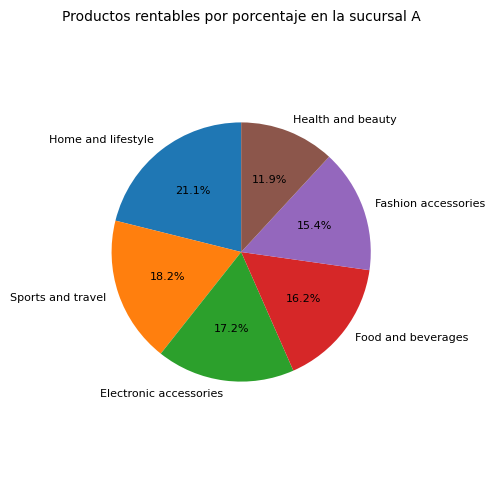

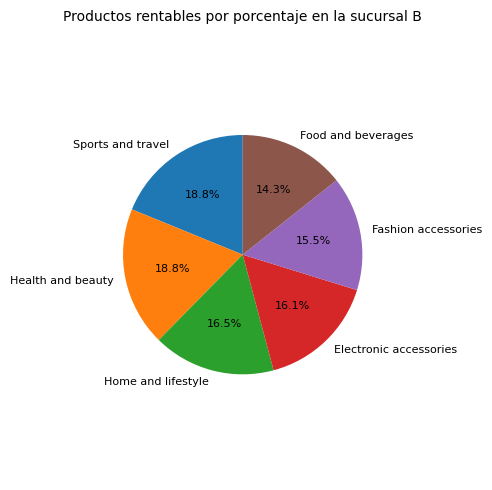

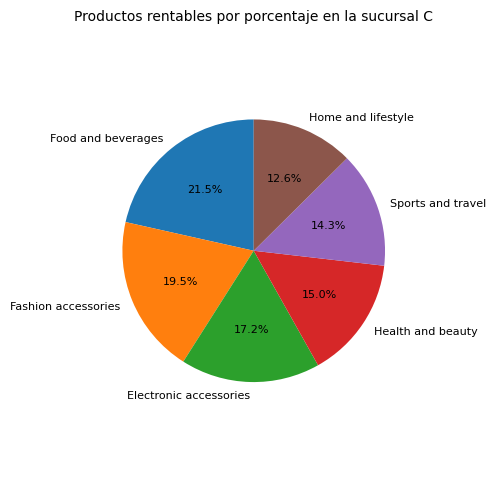

In [19]:
#Graficas de productos más rentables por sucursal, representados en %

#importamos la libreria matplotlib.pyplot
import matplotlib.pyplot as plt

#Agrupamos las sucursales y calculamos el porcentaje de contribución a los ingresos de cada línea de producto dentro de cada sucursal
productos_rentables_sucursal_pct = productos_rentables_sucursal.groupby('branch').apply(lambda x: 100 * x['gross_income'] / float(x['gross_income'].sum()), include_groups=False)


# Generar gráfico circular para cada sucursal
for branch in productos_rentables_sucursal_pct.index.levels[0]:
    branch_data = productos_rentables_sucursal_pct.loc[branch]
    plt.figure(figsize=(5, 5))  # Ajustar tamaño de la figura para mejor visualización

    # Obtener los nombres de las líneas de producto
    product_line_names = productos_rentables_sucursal[productos_rentables_sucursal['branch'] == branch]['product_line'].values

    plt.pie(branch_data, labels=product_line_names, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8}) #Ajustar tamaño de fuente
    plt.title(f'Productos rentables por porcentaje en la sucursal {branch}', fontsize=10) #Ajustar tamaño de fuente
    plt.axis('equal')  # Equal aspecto uniforme garantiza que el gráfico circular se dibuje como un círculo..
    plt.tight_layout() # Ajustar espaciado para evitar que las etiquetas se corten
    plt.show()


PREFERENCIAS DEL CLIENTE

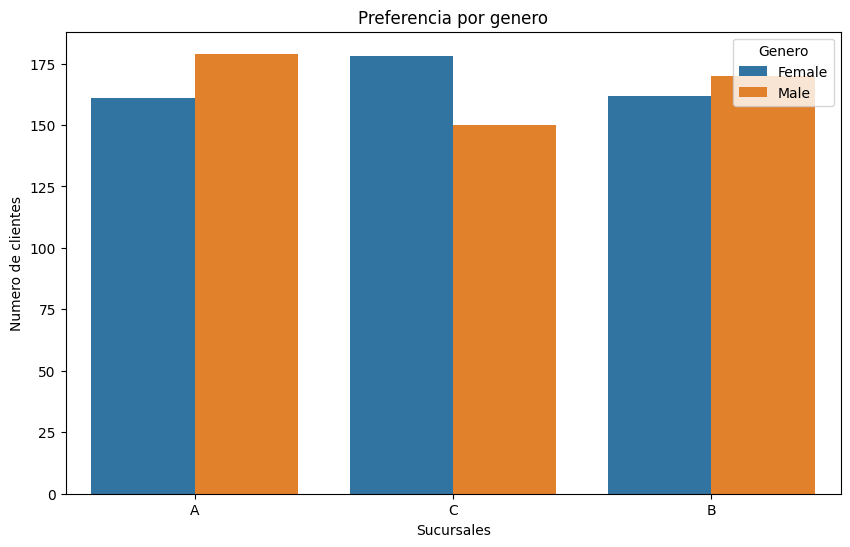

In [20]:
#Grafico de barras con la preferencia de genero por cada Sucursal.

import seaborn as sns

# --- Visualización de la grafica
plt.figure(figsize=(10, 6))
sns.countplot(x='branch', hue='gender_customer', data=data)
plt.title('Preferencia por genero')
plt.xlabel('Sucursales')
plt.ylabel('Numero de clientes')
plt.legend(title='Genero')
plt.show()

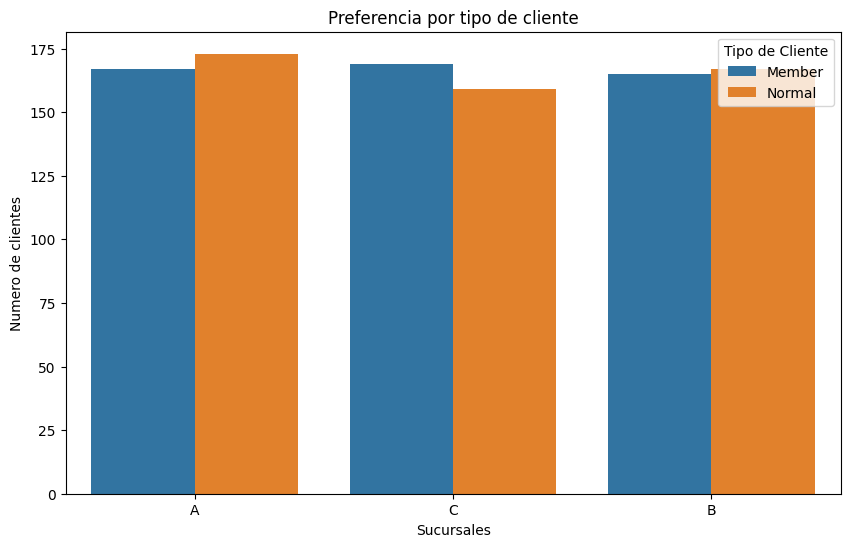

In [21]:
# Grafico de barras con la preferencia de tipo de cliente por cada Sucursal.

# --- Visualización de la grafica
plt.figure(figsize=(10, 6))
sns.countplot(x='branch', hue='customer_type', data=data)
plt.title('Preferencia por tipo de cliente')
plt.xlabel('Sucursales')
plt.ylabel('Numero de clientes')
plt.legend(title='Tipo de Cliente')
plt.show()